In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.signal import savgol_filter
from sklearn.decomposition import PCA

In [72]:
def als_baseline(y, D, L, p = 0.01, niter = 10):
    """
    Asymmetric Least Squares baseline correction.
    
    Parameters:
        y    : spectrum intensity array
        lam  : smoothness (1e3 – 1e7); higher = smoother baseline
        p    : asymmetry (0.001 – 0.1); lower = baseline hugs the bottom
        niter: number of iterations
    """
    w = np.ones(L)

    for _ in range(niter):
        W = sparse.diags(w)
        Z = W + D
        z = spsolve(Z, w*y)
        w = p * (y > z) + (1 - p) * (y <= z)
    return z

In [74]:
df = pd.read_csv("02_feature_matrix_raw_T.csv", header = 0)

dataFrame = df.drop(columns=["Sample_ID", "Replica", "Origin", "Type"])

ranges = [(24, 37), (50, 67), (70, 87), (88, 95), (96, 112), (125, 135), (137, 159)]
indices = np.concatenate([np.arange(s, e) for s, e in ranges])
spectrums = dataFrame.iloc[indices].reset_index(drop=True).copy()
spectrums.iloc[:5, :5].head()


,Spectrum_ID,Subtype,4000.0,3999.0,3998.0
0,25,Cotton,99.10,99.11,99.12
1,26,Cotton,99.26,99.28,99.30
2,27,Cotton,99.89,99.89,99.89
3,28,Cotton,99.59,99.60,99.61
4,29,Cotton,100.71,100.72,100.74


In [75]:
L = spectrums.iloc[:, 2:].shape[1]
D = sparse.diags([1, -2, 1], [0, 1, 2], shape=(L - 2, L))
D = 1e5 * D.T @ D 

corrected = spectrums.copy()

for i in range(spectrums.shape[0]):
    y = spectrums.iloc[i, 2:].values.astype(float)
    baseline = als_baseline(y, D, L)
    corrected.iloc[i, 2:] = y - baseline

meta = corrected.iloc[:, :2].reset_index(drop=True)
values = corrected.iloc[:, 2:].astype(float)
    
normalized = values.copy()

for i in range(values.shape[0]):
    row = values.iloc[i].values
    normalized.iloc[i, :] = (row - row.mean())/row.std()

smoothed = normalized.copy()

for i in range(normalized.shape[0]):
    smoothed.iloc[i, :] = savgol_filter(normalized.iloc[i, :], window_length=9, polyorder=3)

final_df = pd.concat([meta, smoothed], axis=1)

final_df.iloc[:20, :6].head()

,Spectrum_ID,Subtype,4000.0,3999.0,3998.0,3997.0
0,25,Cotton,-0.622644,-0.612657,-0.610001,-0.613199
1,26,Cotton,-0.615384,-0.601185,-0.590786,-0.584005
2,27,Cotton,-0.581537,-0.581484,-0.581587,-0.581481
3,28,Cotton,-0.639473,-0.626938,-0.620960,-0.619838
4,29,Cotton,-0.629731,-0.620984,-0.612284,-0.604668


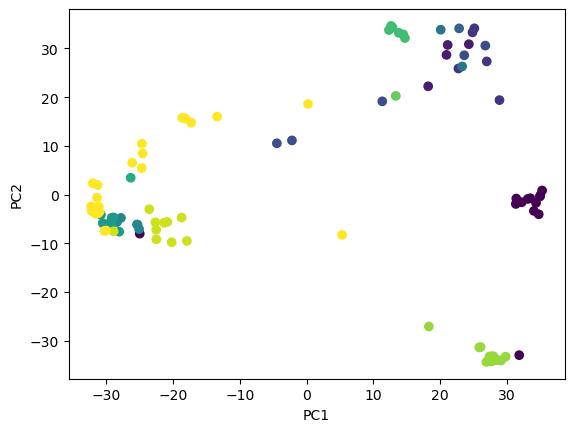

In [ ]:
from matplotlib.pyplot import scatter


pca_data = final_df.copy()
labels = final_df["Subtype"]
codes, uniques = pd.factorize(labels)

pca = PCA(n_components=2)
pca_data = pca.fit_transform(final_df.iloc[:, 2:].values)

plt.scatter(pca_data[:, 0], pca_data[:, 1], c=pd.factorize(labels)[0])
plt.legend(handles = scatter.legend_elements()[0],labels=uniques)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()